I0000 00:00:1776449975.767498   86441 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/arxie/miniconda3/envs/curling/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
W0000 00:00:1776449984.814225   86441 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3030 - loss: 1.3725 - val_accuracy: 0.3435 - val_loss: 1.3407
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4041 - loss: 1.2795 - val_accuracy: 0.5232 - val_loss: 1.1470
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.5981 - loss: 0.9989 - val_accuracy: 0.6685 - val_loss: 0.8618
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7173 - loss: 0.7567 - val_accuracy: 0.7236 - val_loss: 0.7380
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7744 - loss: 0.6147 - val_accuracy: 0.7347 - val_loss: 0.7052


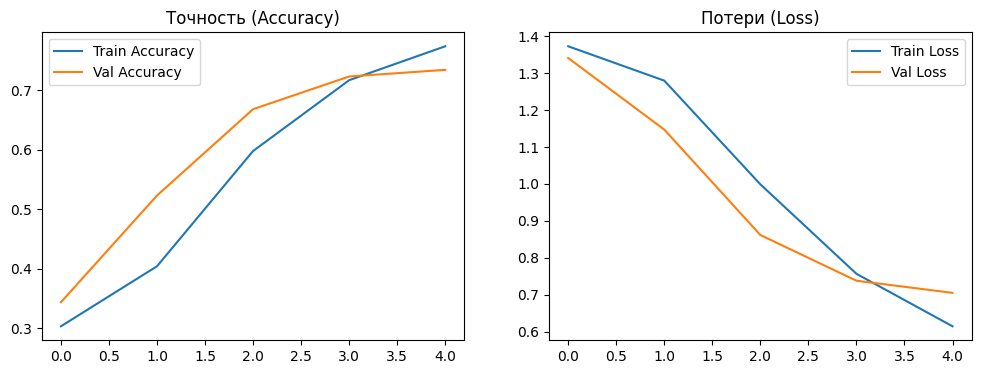

435/435 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.66      0.63      0.64      2474
    Negative       0.75      0.82      0.78      4260
     Neutral       0.74      0.73      0.73      3397
    Positive       0.77      0.72      0.74      3768

    accuracy                           0.74     13899
   macro avg       0.73      0.72      0.73     13899
weighted avg       0.74      0.74      0.74     13899



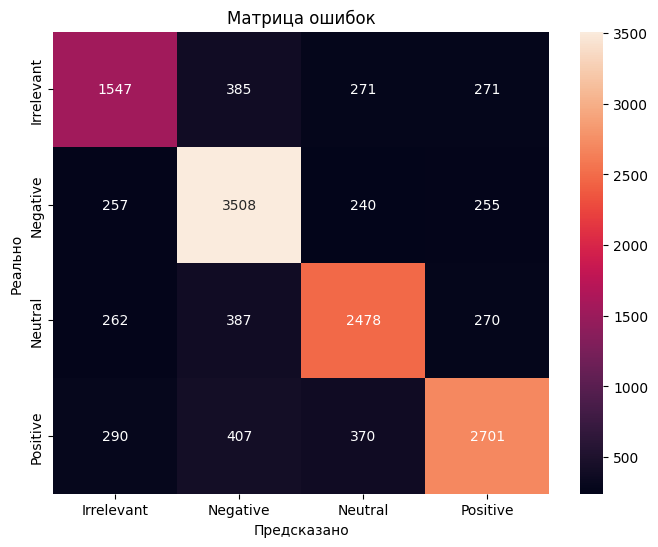

------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Текст: I love this game, it is amazing! 
Результат: Positive

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Текст: The new update is terrible and broken. 
Результат: Negative

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Текст: I am not sure how I feel about the new Nvidia drivers. 
Результат: Neutral

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Текст: Just a normal day playing Borderlands. 
Результат: Positive



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix


df = pd.read_csv('twitter_training.csv', header=None)
df.columns = ['id', 'entity', 'sentiment', 'text']

df = df.dropna(subset=['text'])
df = df.drop_duplicates(subset=['text'])

X = df['text'].astype(str)
y = df['sentiment']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

max_words = 10000  
max_len = 50     

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(sequences, maxlen=max_len)

# Разделение на выборки
X_train, X_test, y_train, y_test = train_test_split(X_pad, y_encoded, test_size=0.2, random_state=42)

# 4. Создание модели SimpleRNN
model = Sequential([
    Embedding(max_words, 64, input_length=max_len),
    SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

# 5. Обучение
epochs = 5
history = model.fit(X_train, y_train, 
                    epochs=epochs, 
                    batch_size=128, 
                    validation_split=0.1, 
                    verbose=1)

# 6. Вывод графиков
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Точность (Accuracy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Потери (Loss)')
plt.legend()
plt.show()

# 7. Метрики и Матрица ошибок
y_pred = np.argmax(model.predict(X_test), axis=-1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Матрица ошибок')
plt.show()

def predict_sentiment(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)
    prediction = model.predict(padded)
    result = label_encoder.inverse_transform([np.argmax(prediction)])
    return result[0]

print("-" * 30)
test_sentences = [
    "I love this game, it is amazing!",
    "The new update is terrible and broken.",
    "I am not sure how I feel about the new Nvidia drivers.",
    "Just a normal day playing Borderlands."
]

for sentence in test_sentences:
    print(f"Текст: {sentence} \nРезультат: {predict_sentiment(sentence)}\n")

In [2]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.2/572.2 MB 1.0 MB/s  0:09:24m0:00:0100:14m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 1.1 MB/s  0:00:06 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 1.4 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 1.2 MB/s  0:00:04 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 1.2 MB/s  0:00:19 eta 0:00:02m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 [tensorflow]0 [tensorflow]-py]
Note: you may need to restart the kernel to use updated packages.
